In [9]:
import os
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

# 1 Fig1

- 充放电信号示意图（重采样前）
- 重采样且平滑后充电过程信号示意图
- 充电过程信号经过卷积层后的特征图
- 模型的预测结果（pred_mean & pred_std as uncertainty）
- 模型的预测结果的标定结果

## 1.1 charge curve

(756,) (756,) (756,)


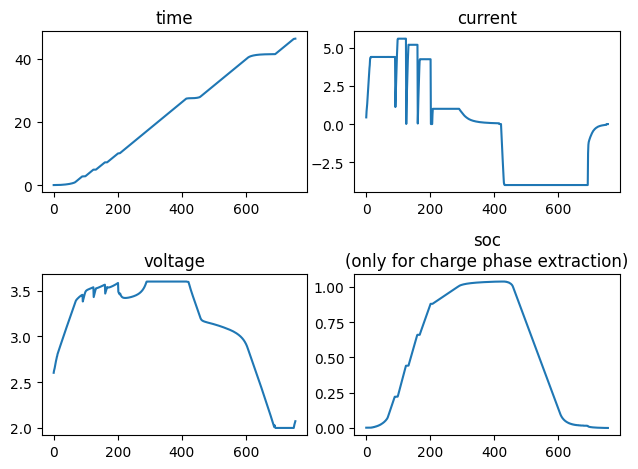

In [10]:
minmiax = False
# raw time series
keys = ['b9c8', 'b9c15', 'b9c18', 'b9c32', 'b9c48']
batch = np.load('../../data/raw/batch9.pkl', allow_pickle=True)
for key in keys:
    if minmiax:
        time = scaler.fit_transform(batch[key]['cycles']['0']['t'].reshape(-1, 1)).flatten()
        current = scaler.fit_transform(batch[key]['cycles']['0']['I'].reshape(-1, 1)).flatten()
        voltage = scaler.fit_transform(batch[key]['cycles']['0']['V'].reshape(-1, 1)).flatten()
        q = scaler.fit_transform((batch[key]['cycles']['0']['Qc'] - batch[key]['cycles']['0']['Qd']).reshape(-1, 1)).flatten()
        plt.plot(time, label='time')
        plt.plot(current, label='current')
        plt.plot(voltage, label='voltage')
        plt.plot(q, label='soc')
        plt.legend()
        plt.tight_layout()
    else:
        # todo 设置横纵坐标
        time = batch[key]['cycles']['0']['t']
        current = batch[key]['cycles']['0']['I']
        voltage = batch[key]['cycles']['0']['V']
        q = batch[key]['cycles']['0']['Qc'] - batch[key]['cycles']['0']['Qd']
        fig, ax = plt.subplots(2, 2)
        ax[0, 0].plot(time)
        ax[0, 0].set_title('time')
        ax[0, 1].plot(current)
        ax[0, 1].set_title('current')
        ax[1, 0].plot(voltage)
        ax[1, 0].set_title('voltage')
        ax[1, 1].plot(q)
        ax[1, 1].set_title('soc\n(only for charge phase extraction)')
        plt.tight_layout()
    break

print(time.shape, current.shape, voltage.shape)
df = pd.DataFrame({'index': list(range(1, len(time) + 1)), 'time': time, 'current': current, 'voltage': voltage})
df.to_excel('input.xlsx', index=False)

In [11]:
# # one step forward
# data = np.load('../../data/mit/b9c8_c16.pkl', allow_pickle=True)
# for sample in data:
#     fig, ax = plt.subplots(16, 1, sharex=True, sharey=False, figsize=(10, 20))
#     for idx, cycle_data in enumerate(sample):
#         ax[idx].plot(cycle_data[0], label=f'timestamp{idx + 1}')
#         ax[idx].legend(loc='lower right')
#     break

## 1.2 feature map

In [12]:
import sys
sys.path.append('../')

In [13]:
import torch
import torch.nn as nn
from main import get_config
from datasets.mit_loader import MITDataset

ModuleNotFoundError: No module named 'main'

In [ ]:
conv = nn.Conv1d(in_channels=16, out_channels=16, kernel_size=1)

args = get_config(notebook=True)
setattr(args, 'data_root_dir', '../data')
setattr(args, 'batch_id', 2)
data_module = MITDataset(args)
data_dict = data_module.get_charge()
test_set = data_dict['test']

['../data/mit/b9c15_c16.pkl', '../data/mit/b9c18_c16.pkl', '../data/mit/b9c32_c16.pkl', '../data/mit/b9c48_c16.pkl', '../data/mit/b9c8_c16.pkl']
test_id: 1
train_id: 2
train_id: 3
train_id: 4
train_id: 5


In [ ]:
input_sample = torch.tensor(test_set[0][0])
heat_map = conv(input_sample.unsqueeze(0))

input_sample = input_sample.numpy()
heat_map = heat_map.squeeze().detach().numpy()

[]

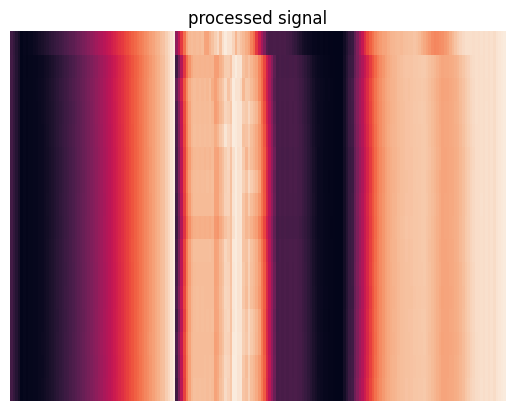

In [ ]:
p = sns.heatmap(input_sample, cbar=False)
p.set_title('processed signal')
p.set_xticks([])
p.set_yticks([])

[]

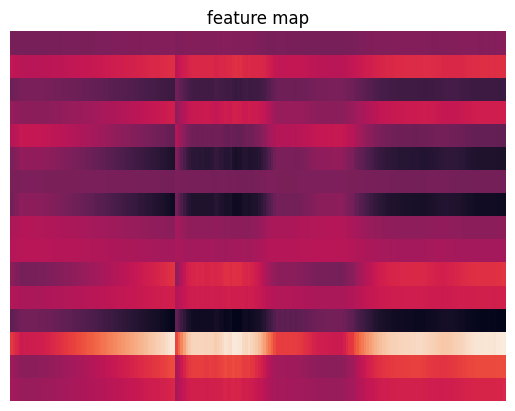

In [ ]:
p = sns.heatmap(heat_map, cbar=False)
p.set_title('feature map')
p.set_xticks([])
p.set_yticks([])

## 1.3 predictive results

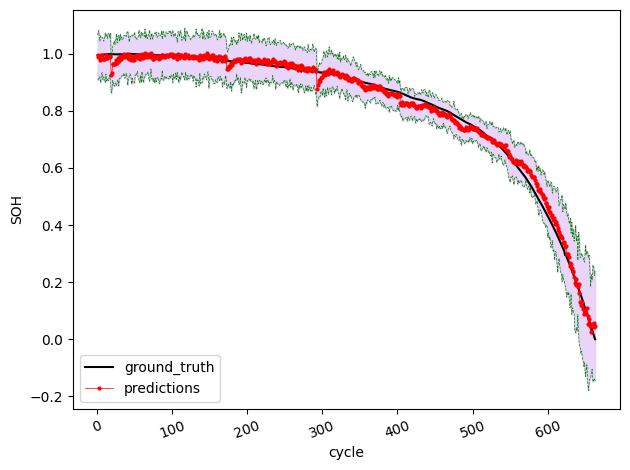

In [ ]:
res_path = '../results/best_new/MHSDT_Dmit_SL16_B2_T2'
res = np.load(os.path.join(res_path, 'gts_mu_sigma_lower_upper.npz'))
res.files
gts, mu, sigma, lower, upper = res['gts'], res['mu'], res['sigma'], res['lower'], res['upper']

plot_index = np.array(range(1, len(gts) + 1))
line1, = plt.plot(plot_index, gts, color='black', lw=1.5, ls='-')
line2, = plt.plot(plot_index, mu, color='red', lw=0.5, marker='o', ms=2)
line3, = plt.plot(plot_index, lower, color='green', lw=0.5, ls='--')
line4, = plt.plot(plot_index, upper, color='green', lw=0.5, ls='--')

plt.fill_between(plot_index, lower, upper, color=(229 / 256, 204 / 256, 249 / 256), alpha=0.8)
plt.xticks(rotation=20)
plt.yticks()
plt.xlabel('cycle')
plt.ylabel('SOH')
plt.legend([line1, line2], ["ground_truth", "predictions"], loc='lower left')
plt.tight_layout()

## 1.4 calibration results

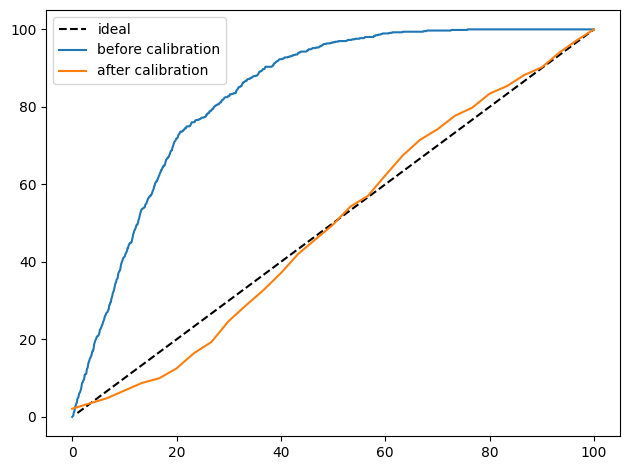

In [ ]:
res_path = '../results/best_new/MHSDT_Dmit_SL16_B2_T2/'
res_before = np.load(os.path.join(res_path, 'exp_obs.npz'))
res_after = np.load(os.path.join(res_path, 'exp_obs_re.npz'))
exp_before, obs_before = res_before['exp'], res_before['obs']
exp_after, obs_after = res_after['exp'], res_after['obs']

plt.plot(range(1, 101), range(1, 101), color='black', linestyle='--', label='ideal')
plt.plot(exp_before, obs_before, label='before calibration')
plt.plot(exp_after, obs_after, label='after calibration')
plt.legend()
plt.tight_layout()

# 2 npy to csv

- 将上一步保存的npy文件保存到csv文件中方便origin绘图